# Basic examples of how to use AJX
While AJX exposes a Simulation class, it is recommended to use or create Environment classes as a wrapper for the simulation.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

rotary_encoder.x: -0.6331525444984436


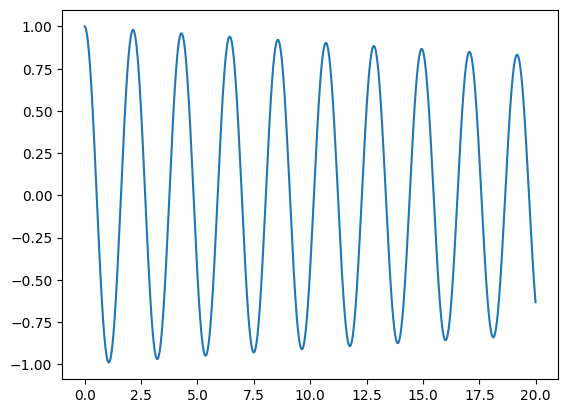

In [2]:
from ajx.example_environments import Pendulum
from ajx.simulation import SimulationSettings
import matplotlib.pyplot as plt
import numpy as np

# Create a pendulum environment
env = Pendulum(SimulationSettings(timestep=0.01), has_quadratic_damping=False)

# Use the default parameters
env_param = env.default_param.tree_replace({})

# Get the initial state by specifying in angle
state = env.state_from_angle(1.0, env_param)

# Allocate an array to store the observations over time
observation_array = np.zeros([2000])

# Simulation loop
for i in range(2000):
    # Step the environment and store the observation
    state, observations = env.step(state, None, env_param)
    observation_array[i] = observations[0]
plt.plot(np.arange(2000)*env.sim.settings.timestep, observation_array)
print("\t".join(env.observation_strings(observations)))


### Parallel Simulation Example
Below are examples of how AJX simulations can be stepped in parallel. For an ensemble of simulations that share the same constraint graph, `jax.vmap` can be used to run them in parallel. This is always the case for ensambles of the same AJX environment (since geometry, collisions, and inequality constraints are not supported).

For heterogeneous ensembles, or for simulations involving contact, the recommended approach is to pass all data to the solver as a single simulation rather than using `jax.vmap`. However, the current AJX solvers are not well-suited for this approach yet.

Text(0, 0.5, 'Angle (rad)')

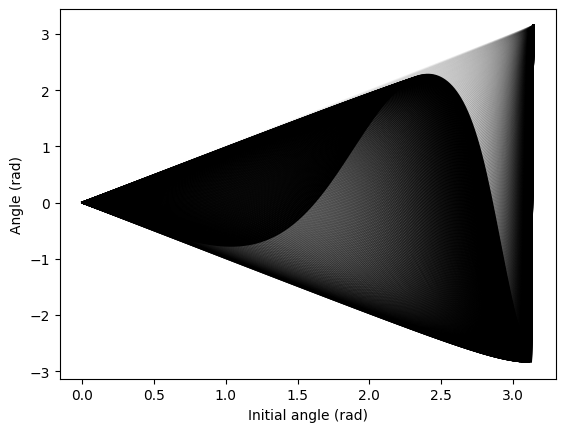

In [3]:
# Example with different initial conditions
import jax.numpy as jnp
from jax import vmap

# Create an array of initial angles 
initial_angles = jnp.linspace(0, jnp.pi, 200)

# Use vmap to get an ensemble of initial states
states = vmap(env.state_from_angle, in_axes=(0, None))(initial_angles, env_param)

for i in range(300):
    # Use vmap to step the ensemble
    states, observations = vmap(env.step, in_axes=(0, None, None))(
        states, None, env_param
    )
    # Plot the angles versus initial angles
    plt.plot(initial_angles, observations.flatten(), color=(0, 0, 0, i / 300))

plt.xlabel("Initial angle (rad)")
plt.ylabel("Angle (rad)")

In [ ]:

# TODO: This block is broken...
# Example with different simulation parameters
n_simulations = 200

# Create parameter array
damping_ensemble = jnp.linspace(1e-5, 1e-1, n_simulations)
holonomic_compliance_ensemble = jnp.repeat(
    1e-5 * jnp.ones([n_simulations])[:, None, None], 5, axis=2
)
full_compliance_ensemble = jnp.concatenate(
    [holonomic_compliance_ensemble, 1 / damping_ensemble[:, None, None]], axis=2
)
# Create a new SimulationParameters object with a compliance array that has an extra dimension
env_param = env.default_param.tree_replace(
    {
        "constraint_param.compliance":  full_compliance_ensemble,
    }
)
# Use the same initial angle for all simulations
initial_angles = jnp.ones([n_simulations]) * 2.0
states = vmap(env.state_from_angle, in_axes=(0, None))(initial_angles, env_param)

# Create in_axis object that specifies what key to map over (broken)
in_axes_simulation_param = env_param.create_in_axes(
    {"constraint_param": env_param.constraint_param.create_in_axes({"compliance": 0})}
)

for i in range(400):
    states, observations = vmap(env.step, in_axes=(0, None, in_axes_simulation_param))(
        states, None, env_param
    )
    # Plot the angles versus damping
    plt.plot(damping_ensemble, observations.flatten(), color=(0, 0, 0, i / 400))

plt.xlabel("Viscous damping")
plt.ylabel("Angle (rad)")


ValueError: vmap in_axes specification must be a tree prefix of the corresponding value, got specification (0, None, SimulationParameters(gravity=None, rigid_body_param=None, constraint_param=ConstraintParameters(names=('hinge',), frame_a=None, frame_b=None, compliance=0, damping=None, target=None, is_velocity=None), sparse_param=None, scalar_body_param=None, scalar_constraint_param=None, tangent_restrictions=None)) for value tree PyTreeDef((CustomNode(State[()], [CustomNode(Configuration[()], [*, *, *]), CustomNode(GeneralizedVelocity[()], [*, *])]), None, CustomNode(SimulationParameters[((),)], [*, CustomNode(RigidBodyParameters[(('pendulum',),)], [*, *, *]), CustomNode(ConstraintParameters[(('hinge',),)], [CustomNode(Frames[()], [*, *]), CustomNode(Frames[()], [*, *]), *, *, *, *]), CustomNode(PendulumSparseParam[()], [CustomNode(QuadraticDampingParameters[()], [*, *]), CustomNode(OffsetParameters[('rotary_encoder',)], [(*,), (*,)])]), CustomNode(ScalarBodyParameters[((),)], [*, *])

In [ ]:
from ajx import RigidBodyParameters

# Option 1
body1_param = RigidBodyParameters.create(1.0, [0.4, 0.5, 0.6], "body1")
body2_param = RigidBodyParameters.create(2.0, [0.7, 0.8, 0.9], "body2")
rb_param = RigidBodyParameters.concatenate([body1_param, body2_param])

# Option 2
rb_param = RigidBodyParameters(
    ("body1", "body2"),
    mass=jnp.array([1.0, 2.0]),
    mc=jnp.zeros([2,3]),
    inertia=jnp.array([[0.4, 0., 0., 0.5, 0., 0.6], [0.7, 0., 0., 0.8, 0., 0.9]]),
)

# Getting parameter values
mass = rb_param.get_value_at_path("mass.body1")
print(f"Mass is {mass}")

# Overwriting parameter values
rb_param2 = rb_param.tree_replace({"mass.body1": 3.0, "inertia.body1.xx": 1.0})
new_mass = rb_param2.get_value_at_path("mass.body1")
new_inertia = rb_param2.get_value_at_path("inertia.body1")
print(f"Updates mass is {new_mass}")
print(f"Updates inertia is {new_inertia}")

Mass is 1.0
Updates mass is 3.0
Updates inertia is [1.  0.  0.  0.5 0.  0.6]
